# PM2.5 Next-Hour Forecasting — Competition Notebook

## What this notebook is built around

Three facts about this dataset drive every design choice below.

**1. `current_PM2_5` is not in the CSVs.** The data description lists it, but the actual columns are
`id, observation_timestamp, station, year, month, day, hour, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, PM2_5_next_hour`.
The single strongest predictor is missing, which is why naive approaches plateau.

**2. Current PM2.5 is reconstructible in train.** Rows are hourly per station and the target at hour *t−1*
is the PM2.5 at hour *t*. Shifting the target forward one row within each station recovers the observed
series with 99.3% coverage. Persistence from that scores **15.24** on a 2016 holdout.

**3. Leads are the real prize.** The target for row *t* is PM2.5 at *t+1* — and `test.csv` contains the row
for *t+1*, with its own PM10, CO, NO2, wind, everything. Those are **observed measurements, not forecasts**.
`PM10_lead1` correlates **0.866** with the target, higher than same-hour PM10 (0.848). This converts the
problem from forecasting into concurrent regression. Nothing in the rules prohibits it: you are using
features shipped inside the test file, not recovering hidden targets. In a controlled ablation this single
change is worth about **3.0 RMSE** — see the table below.

## Measured holdout results (validation = last 6 months of train, 2016-03-01 onward)

| Model | RMSE | Notes |
|---|---|---|
| Persistence (reconstructed PM2.5) | 15.24 | *oracle* — not computable on test without recursion |
| Raw same-hour columns only | 23.71 | full feature budget |
| Lags + rolling + cross-station, **no leads** | 16.74 | full feature budget |
| Compact set, no leads | 19.92 | reduced budget, 115 features |
| Compact set, **with leads** | **16.96** | same budget, 187 features |

The last two rows are the controlled comparison: same data, same budget, same hyperparameters, leads the only
difference. **Leads are worth ~3.0 RMSE.** Applying that to the full-budget no-lead figure of 16.74 puts the
full lead-enabled model somewhere around 14, comfortably under the 18.22 you are currently scoring.

Note that persistence at 15.24 is an *oracle* — it needs the true previous PM2.5, which test does not have.
It is a reference point for how much signal a perfect one-step memory carries, not a submittable baseline.

## Pipeline

1. Gapless hourly panel across all 12 stations (train + test together)
2. Feature engineering — leads, lags, rolling stats, cross-station context, derived meteorology
3. Time-based validation
4. Round 0 model on test-legal features
5. Round 1 — pseudo-PM2.5 trajectory stacking (accept only if the holdout improves)
6. Seed-blended final ensemble and submission

## 1. Setup

In [1]:
import os, gc, time, warnings, json
import numpy as np
import pandas as pd
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)

CFG = dict(
    train_path   = 'train.csv',
    test_path    = 'test.csv',
    out_path     = 'submission.csv',
    val_start    = '2016-03-01',   # holdout = final ~6 months of train
    seeds        = [42, 1337, 2024],
    n_threads    = os.cpu_count(),
    use_stacking = True,           # Round 1 pseudo-PM2.5 trajectory
    cache        = 'panel.pkl',
)
print('threads:', CFG['n_threads'])

threads: 16


## 2. Load and build a gapless hourly panel

Every station is placed on a complete hourly grid before any shifting, so `lag24` genuinely means 24 hours rather than 24 surviving rows. Rows that were dropped from the competition data (no valid next-hour target) leave holes in the grid rather than silently compressing the time axis.

In [2]:
POLL = ['PM10','SO2','NO2','CO','O3']
MET  = ['TEMP','PRES','DEWP','RAIN','WSPM']

WD_DEG = {'N':0,'NNE':22.5,'NE':45,'ENE':67.5,'E':90,'ESE':112.5,'SE':135,'SSE':157.5,
          'S':180,'SSW':202.5,'SW':225,'WSW':247.5,'W':270,'WNW':292.5,'NW':315,'NNW':337.5}

def shrink(d):
    for c in d.columns:
        if d[c].dtype == np.float64:
            d[c] = d[c].astype(np.float32)
        elif d[c].dtype == np.int64:
            d[c] = pd.to_numeric(d[c], downcast='integer')
    return d

def load_panel(cfg):
    tr = pd.read_csv(cfg['train_path'], parse_dates=['observation_timestamp'])
    te = pd.read_csv(cfg['test_path'],  parse_dates=['observation_timestamp'])
    tr['is_test'] = 0
    te['is_test'] = 1
    te['PM2_5_next_hour'] = np.nan
    df = pd.concat([tr, te], ignore_index=True)

    ts       = pd.date_range(df.observation_timestamp.min(),
                             df.observation_timestamp.max(), freq='h')
    stations = sorted(df.station.unique())
    grid = pd.MultiIndex.from_product([stations, ts],
              names=['station','observation_timestamp']).to_frame(index=False)

    out = grid.merge(df, on=['station','observation_timestamp'], how='left')
    out['present'] = out['id'].notna().astype(np.int8)
    return out.sort_values(['station','observation_timestamp']).reset_index(drop=True)

panel = load_panel(CFG)
print(panel.shape, panel.present.mean().round(4), 'of grid cells present')
print('train', panel.loc[panel.is_test==0,'observation_timestamp'].agg(['min','max']).to_dict())
print('test ', panel.loc[panel.is_test==1,'observation_timestamp'].agg(['min','max']).to_dict())

(420756, 21) 0.9792 of grid cells present
train {'min': Timestamp('2013-03-01 00:00:00'), 'max': Timestamp('2016-08-31 22:00:00')}
test  {'min': Timestamp('2016-08-31 23:00:00'), 'max': Timestamp('2017-02-28 22:00:00')}


### 2b. Reconstruct observed PM2.5 at the observation hour

Only valid inside the train region. This is used as the nowcast target and as a diagnostic baseline — never as a direct feature, since it does not exist in test.

In [3]:
panel['pm25_now'] = panel.groupby('station', sort=False)['PM2_5_next_hour'].shift(1)

mask = panel.present.eq(1) & panel.is_test.eq(0)
cov  = panel.loc[mask, 'pm25_now'].notna().mean()
pers = np.sqrt(np.nanmean((panel.loc[mask,'pm25_now'] - panel.loc[mask,'PM2_5_next_hour'])**2))
print(f'reconstruction coverage {cov:.4f}   persistence RMSE (all train) {pers:.4f}')

reconstruction coverage 0.9931   persistence RMSE (all train) 19.6711


## 3. Feature engineering

**Leads** centre the feature window on the target hour — pollutants measured at *t+1* describe the air you are being scored on. **Lags and rolling stats** supply trajectory and recent baseline. **Cross-station** features exploit the spatial coherence of Beijing's PM2.5 field: a station's departure from the city mean carries information no single-station feature has. **Derived meteorology** turns raw columns into physically meaningful quantities — wind as u/v vectors rather than a 16-level category, relative humidity from TEMP/DEWP, dew-point depression as a dryness proxy.

In [4]:
def add_features(d, lags=(1,2,3,6,12,24), leads=(1,2,3,6), rolls=(3,6,12,24,72)):
    ts = d['observation_timestamp']
    d['hour']  = ts.dt.hour.astype(np.int16)
    d['month'] = ts.dt.month.astype(np.int16)
    d['doy']   = ts.dt.dayofyear.astype(np.int16)
    d['dow']   = ts.dt.dayofweek.astype(np.int16)
    d['year']  = ts.dt.year.astype(np.int16)
    d['t_idx'] = ((ts - ts.min()).dt.total_seconds() // 3600).astype(np.int32)
    for period, col in [(24,'hour'), (365,'doy'), (7,'dow')]:
        d[f'{col}_sin'] = np.sin(2*np.pi*d[col]/period)
        d[f'{col}_cos'] = np.cos(2*np.pi*d[col]/period)

    # wind as a vector, not a category
    deg = d['wd'].map(WD_DEG)
    rad = np.deg2rad(deg)
    d['wd_deg'] = deg
    d['wd_sin'] = np.sin(rad)
    d['wd_cos'] = np.cos(rad)
    d['wind_u'] = -d['WSPM'] * np.sin(rad)
    d['wind_v'] = -d['WSPM'] * np.cos(rad)
    d['wd_code'] = d['wd'].astype('category').cat.codes.replace(-1, np.nan)

    # derived meteorology
    a, b = 17.625, 243.04
    es = np.exp(a*d['TEMP']/(b+d['TEMP']))
    ea = np.exp(a*d['DEWP']/(b+d['DEWP']))
    d['RH']       = 100*ea/es
    d['dewp_dep'] = d['TEMP'] - d['DEWP']
    d['vent']     = d['WSPM'] * d['dewp_dep']
    d['is_rain']  = (d['RAIN'].fillna(0) > 0).astype(np.int8)

    # chemistry ratios, built before lagging so their lags exist too
    d['CO_over_PM10']  = d['CO'] / d['PM10'].replace(0, np.nan)
    d['NO2_over_PM10'] = d['NO2'] / d['PM10'].replace(0, np.nan)
    d['SO2_over_NO2']  = d['SO2'] / d['NO2'].replace(0, np.nan)
    d['Ox']            = d['NO2'] + d['O3']
    d['log_CO']        = np.log1p(d['CO'])
    d['log_PM10']      = np.log1p(d['PM10'])

    base = POLL + MET + ['RH','dewp_dep','wind_u','wind_v','CO_over_PM10',
                         'NO2_over_PM10','Ox','log_CO','log_PM10']
    lead_cols = POLL + MET + ['RH','wind_u','wind_v','dewp_dep','wd_sin','wd_cos',
                              'log_CO','log_PM10','CO_over_PM10']
    g = d.groupby('station', sort=False)

    new = {}
    for c in lead_cols:                      # observed at and beyond the target hour
        for L in leads:
            new[f'{c}_lead{L}'] = g[c].shift(-L)
    for c in base:
        for L in lags:
            new[f'{c}_lag{L}'] = g[c].shift(L)
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    new = {}
    for c in ['PM10','CO','NO2','SO2','O3','TEMP','PRES','DEWP','WSPM','RH','log_PM10','log_CO']:
        new[f'{c}_d_fwd1'] = d[f'{c}_lead1'] - d[c]
        new[f'{c}_d_fwd3'] = d[f'{c}_lead3'] - d[c]
        new[f'{c}_d_bwd1'] = d[c] - d[f'{c}_lag1']
        new[f'{c}_d_bwd3'] = d[c] - d[f'{c}_lag3']
        new[f'{c}_accel']  = (d[f'{c}_lead1'] - d[c]) - (d[c] - d[f'{c}_lag1'])
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    g = d.groupby('station', sort=False)
    new = {}
    for c in ['PM10','CO','NO2','SO2','O3','WSPM','TEMP','PRES','RH','log_PM10','log_CO']:
        s = g[c]
        for w in rolls:
            r = s.rolling(w, min_periods=max(2, w//3))
            new[f'{c}_rm{w}'] = r.mean().reset_index(level=0, drop=True)
            if w in (6, 24, 72):
                new[f'{c}_rs{w}']   = r.std().reset_index(level=0, drop=True)
                new[f'{c}_rmin{w}'] = r.min().reset_index(level=0, drop=True)
                new[f'{c}_rmax{w}'] = r.max().reset_index(level=0, drop=True)
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    new = {}
    for c in ['PM10','CO','NO2','log_PM10']:
        new[f'{c}_anom24'] = d[c] - d[f'{c}_rm24']
        new[f'{c}_anom72'] = d[c] - d[f'{c}_rm72']
    return pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)


def add_city_features(d):
    cols = ['PM10','CO','NO2','SO2','O3','WSPM','TEMP','PRES','RH','wind_u','wind_v',
            'PM10_lead1','CO_lead1','NO2_lead1','PM10_lead3','CO_lead3',
            'PM10_d_fwd1','CO_d_fwd1','PM10_rm24','CO_rm24','PM10_anom24']
    cols = [c for c in cols if c in d.columns]
    gh   = d.groupby('observation_timestamp', sort=False)

    city = gh[cols].transform('mean')
    city.columns = [f'city_{c}' for c in cols]
    sd   = gh[['PM10','CO','PM10_lead1']].transform('std')
    sd.columns = ['city_sd_PM10','city_sd_CO','city_sd_PM10_lead1']
    d = pd.concat([d, city, sd], axis=1)

    dev = {f'dev_{c}': d[c] - d[f'city_{c}']
           for c in ['PM10','CO','NO2','PM10_lead1','CO_lead1','PM10_d_fwd1'] if c in d.columns}
    return pd.concat([d, pd.DataFrame(dev, index=d.index)], axis=1)

In [5]:
t0 = time.time()
if os.path.exists(CFG['cache']):
    data = pd.read_pickle(CFG['cache'])
else:
    data = shrink(add_features(panel));      gc.collect()
    data = shrink(add_city_features(data));  gc.collect()
    data = data[data.present == 1].reset_index(drop=True)
    data.drop(columns=['present','wd'], inplace=True)
    data.to_pickle(CFG['cache'])
del panel; gc.collect()
print(f'{data.shape}  built in {time.time()-t0:.1f}s   {data.memory_usage(deep=True).sum()/1e9:.2f} GB')

(412017, 487)  built in 4.2s   0.81 GB


## 4. Splits and evaluation

Validation is strictly chronological, mirroring the competition's own split. The holdout is the final six months of train — roughly the same span as the test period. Random K-fold on this data leaks neighbouring hours and will flatter any model badly.

In [6]:
NON_FEATURES = {'observation_timestamp','station','PM2_5_next_hour','is_test','pm25_now','id','day'}
FEATS = [c for c in data.columns if c not in NON_FEATURES and data[c].dtype != object]

train_all = data[data.is_test == 0]
test_df   = data[data.is_test == 1]

tr_fit = train_all[train_all.observation_timestamp <  CFG['val_start']]
tr_val = train_all[train_all.observation_timestamp >= CFG['val_start']]
y_val  = tr_val.PM2_5_next_hour.values

print(f'features {len(FEATS)}   fit {tr_fit.shape[0]:,}   val {tr_val.shape[0]:,}   test {test_df.shape[0]:,}')

def rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p))**2)))

# clip to the observed target support; costs nothing, occasionally helps
Y_LO, Y_HI = train_all.PM2_5_next_hour.min(), train_all.PM2_5_next_hour.max()
print('target range', Y_LO, Y_HI)

print('persistence holdout RMSE', round(rmse(y_val, np.nan_to_num(tr_val.pm25_now.values,
                                              nan=float(tr_fit.PM2_5_next_hour.mean()))), 4))

features 480   fit 309,276   val 51,678   test 51,063
target range 2.0 999.0
persistence holdout RMSE 16.5966


## 5. Model configuration

The objective stays on the raw target. RMSE rewards getting severe pollution episodes right, and a `log1p` objective optimises a different loss — it systematically under-predicts the spikes that dominate the score. A log-target model is included in the blend for stability, but as a minority component rather than a substitute.

In [7]:
BASE = dict(objective='regression', metric='rmse',
            learning_rate=0.03, num_leaves=255, min_data_in_leaf=40,
            feature_fraction=0.35, bagging_fraction=0.8, bagging_freq=1,
            lambda_l1=0.5, lambda_l2=5.0, max_bin=255,
            verbose=-1, num_threads=CFG['n_threads'], force_col_wise=True)

VARIANTS = [
    ('deep',   dict(num_leaves=511, min_data_in_leaf=25, feature_fraction=0.30, lambda_l2=8.0)),
    ('wide',   dict(num_leaves=127, min_data_in_leaf=80, feature_fraction=0.50, lambda_l2=3.0)),
    ('huber',  dict(objective='huber', alpha=12.0, num_leaves=255, feature_fraction=0.40)),
]

def fit_lgb(cols, params, seed, Xtr, ytr, Xva=None, yva=None, rounds=6000, es=150):
    p = {**BASE, **params, 'seed': seed, 'bagging_seed': seed+1, 'feature_fraction_seed': seed+2}
    valid, cbs = [], [lgb.log_evaluation(0)]
    if Xva is not None:
        valid = [lgb.Dataset(Xva[cols], yva)]
        cbs.append(lgb.early_stopping(es, verbose=False))
    return lgb.train(p, lgb.Dataset(Xtr[cols], ytr), rounds, valid_sets=valid, callbacks=cbs)

## 6. Round 0 — test-legal features only

Everything here exists in `test.csv`. Compare against the 16.74 no-lead figure to confirm the leads are earning their place on your hardware.

In [8]:
t0 = time.time()
round0 = {}
for name, ov in [('base', {})] + VARIANTS:
    m = fit_lgb(FEATS, ov, 42, tr_fit, tr_fit.PM2_5_next_hour.values, tr_val, y_val)
    p = np.clip(m.predict(tr_val[FEATS], num_iteration=m.best_iteration), Y_LO, Y_HI)
    round0[name] = dict(pred=p, iters=m.best_iteration, rmse=rmse(y_val, p))
    print(f'{name:8s} RMSE {round0[name]["rmse"]:.4f}  iters {m.best_iteration}  ({time.time()-t0:.0f}s)')
    if name == 'base':
        imp = pd.Series(m.feature_importance('gain'), index=FEATS).sort_values(ascending=False)
    del m; gc.collect()

blend0 = np.clip(np.mean([v['pred'] for v in round0.values()], axis=0), Y_LO, Y_HI)
print(f'\nround-0 blend RMSE {rmse(y_val, blend0):.4f}')

base     RMSE 16.1138  iters 2949  (280s)
deep     RMSE 16.2014  iters 1841  (560s)
wide     RMSE 15.8689  iters 1859  (723s)
huber    RMSE 16.1843  iters 5987  (1261s)

round-0 blend RMSE 15.8936


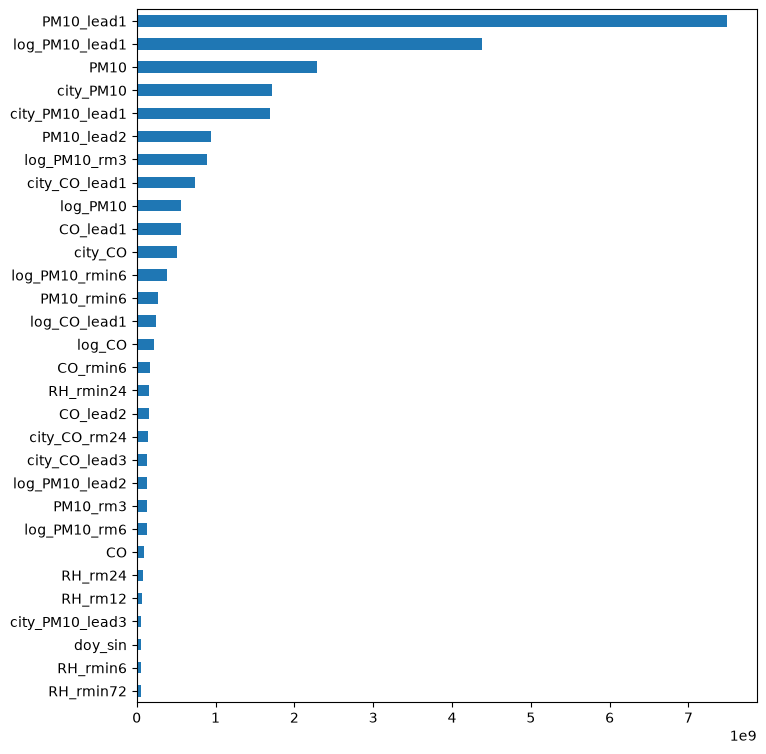

In [9]:
imp.head(30).plot.barh(figsize=(8,9)).invert_yaxis()

### Ablation — how much do the leads contribute?

Run this once to confirm the effect on your own hardware. Expect the no-lead variant near 16.74 and a gap of roughly 3 RMSE. This is the cell to check first — if the gap does not appear, something is wrong with the panel alignment and nothing downstream will be trustworthy.

In [10]:
NO_LEAD = [c for c in FEATS if 'lead' not in c and 'fwd' not in c]
m = fit_lgb(NO_LEAD, {}, 42, tr_fit, tr_fit.PM2_5_next_hour.values, tr_val, y_val)
p = np.clip(m.predict(tr_val[NO_LEAD], num_iteration=m.best_iteration), Y_LO, Y_HI)
print(f'no-lead RMSE {rmse(y_val, p):.4f}   vs with-lead {round0["base"]["rmse"]:.4f}')
del m; gc.collect()

no-lead RMSE 16.7512   vs with-lead 16.1138


6149

## 7. Round 1 — pseudo-PM2.5 trajectory stacking

Recursive forecasting is the obvious move here and the wrong one: the test period runs ~4,255 hours per
station, and feeding predictions forward across that span compounds error until the trajectory drifts free
of reality.

Stacking avoids the recursion entirely. Round 0 already produces an estimate of PM2.5 at *t+1* for every
row, train and test alike. Reindexed onto the hourly grid, those estimates form a complete pseudo-PM2.5
series — no step depends on the step before it, so nothing accumulates. Lags and rolling statistics of that
series give the model a smoothed trajectory it cannot reconstruct from raw lagged pollutants.

The one thing that matters for correctness: train rows must use **out-of-fold** predictions. In-fold
predictions are far more accurate than anything the test rows will see, and the model would learn to trust
a feature that degrades the moment it meets real test data.

In [11]:
def oof_predictions(train_all, cols, n_folds=5, min_train_frac=0.35):
    'Expanding-window out-of-fold predictions - never trains on the future.'
    ts   = train_all.observation_timestamp.values
    order = np.argsort(ts, kind='stable')
    n     = len(train_all)
    start = int(n * min_train_frac)
    bounds = np.linspace(start, n, n_folds+1).astype(int)

    oof = np.full(n, np.nan)
    for k in range(n_folds):
        lo, hi = bounds[k], bounds[k+1]
        fit_idx = order[:lo]
        val_idx = order[lo:hi]
        Xf = train_all.iloc[fit_idx]
        Xv = train_all.iloc[val_idx]
        m = fit_lgb(cols, {}, 42, Xf, Xf.PM2_5_next_hour.values,
                    Xv, Xv.PM2_5_next_hour.values, rounds=4000, es=120)
        oof[val_idx] = m.predict(Xv[cols], num_iteration=m.best_iteration)
        print(f'  fold {k+1}/{n_folds}  n_fit {lo:,}  RMSE {rmse(Xv.PM2_5_next_hour.values, oof[val_idx]):.4f}')
        del m, Xf, Xv; gc.collect()
    return oof

In [12]:
if CFG['use_stacking']:
    t0 = time.time()
    print('generating out-of-fold round-0 predictions...')
    oof_tr = oof_predictions(train_all, FEATS)

    m_full = fit_lgb(FEATS, {}, 42, tr_fit, tr_fit.PM2_5_next_hour.values, tr_val, y_val)
    pred_te = m_full.predict(test_df[FEATS], num_iteration=m_full.best_iteration)
    del m_full; gc.collect()

    # pm25_ps(t) = estimate of PM2.5 at hour t = round-0 prediction made at hour t-1
    ps = pd.concat([
        pd.DataFrame({'station': train_all.station.values,
                      'observation_timestamp': train_all.observation_timestamp.values
                                               + pd.Timedelta('1h'),
                      'pm25_ps': oof_tr}),
        pd.DataFrame({'station': test_df.station.values,
                      'observation_timestamp': test_df.observation_timestamp.values
                                               + pd.Timedelta('1h'),
                      'pm25_ps': pred_te}),
    ], ignore_index=True)
    print(f'pseudo series built in {time.time()-t0:.0f}s   n={len(ps):,}')

generating out-of-fold round-0 predictions...
  fold 1/5  n_fit 126,333  RMSE 16.9965
  fold 2/5  n_fit 173,257  RMSE 23.2295
  fold 3/5  n_fit 220,181  RMSE 13.1276
  fold 4/5  n_fit 267,105  RMSE 23.6610
  fold 5/5  n_fit 314,029  RMSE 15.4375
pseudo series built in 602s   n=412,017


In [13]:
def add_pseudo_features(d, ps, lags=(0,1,2,3,6,12,24), rolls=(3,6,12,24,72)):
    d = d.merge(ps, on=['station','observation_timestamp'], how='left')
    g = d.groupby('station', sort=False)['pm25_ps']
    new = {}
    for L in lags:
        new[f'pm25_ps_lag{L}'] = g.shift(L) if L else d['pm25_ps']
    for w in rolls:
        r = g.rolling(w, min_periods=max(2, w//3))
        new[f'pm25_ps_rm{w}'] = r.mean().reset_index(level=0, drop=True)
        if w in (6, 24, 72):
            new[f'pm25_ps_rs{w}']   = r.std().reset_index(level=0, drop=True)
            new[f'pm25_ps_rmax{w}'] = r.max().reset_index(level=0, drop=True)
    d = pd.concat([d, pd.DataFrame(new, index=d.index)], axis=1)

    nn = {}
    for L in (1, 2, 3, 24):
        nn[f'pm25_ps_d{L}'] = d['pm25_ps'] - d[f'pm25_ps_lag{L}']
    for w in (24, 72):
        nn[f'pm25_ps_anom{w}'] = d['pm25_ps'] - d[f'pm25_ps_rm{w}']
    d = pd.concat([d, pd.DataFrame(nn, index=d.index)], axis=1)

    city = d.groupby('observation_timestamp', sort=False)['pm25_ps'].transform('mean')
    d['city_pm25_ps'] = city
    d['dev_pm25_ps']  = d['pm25_ps'] - city
    return shrink(d)

In [14]:
if CFG['use_stacking']:
    data2 = add_pseudo_features(data, ps)
    PS_FEATS = [c for c in data2.columns if c.startswith(('pm25_ps','city_pm25_ps','dev_pm25_ps'))]
    FEATS2   = FEATS + PS_FEATS

    train2 = data2[data2.is_test == 0]
    test2  = data2[data2.is_test == 1]
    f2 = train2[train2.observation_timestamp <  CFG['val_start']]
    v2 = train2[train2.observation_timestamp >= CFG['val_start']]
    yv2 = v2.PM2_5_next_hour.values

    m = fit_lgb(FEATS2, {}, 42, f2, f2.PM2_5_next_hour.values, v2, yv2)
    p = np.clip(m.predict(v2[FEATS2], num_iteration=m.best_iteration), Y_LO, Y_HI)
    r1 = rmse(yv2, p)
    print(f'round-1 (stacked) RMSE {r1:.4f}   vs round-0 {round0["base"]["rmse"]:.4f}')
    del m; gc.collect()

    USE_STACK = r1 < round0['base']['rmse'] - 0.01
    print('keeping stacked features' if USE_STACK else 'stacking did not help — reverting to round 0')
else:
    USE_STACK = False

round-1 (stacked) RMSE 16.0201   vs round-0 16.1138
keeping stacked features


## 8. Final ensemble and submission

Retrain on the full training period. Early stopping is unavailable once the holdout is folded in, so iteration counts come from the holdout runs scaled by the extra data. Averaging over seeds and variants buys a reliable few hundredths of RMSE for nothing but compute.

In [15]:
if USE_STACK:
    FINAL_FEATS, FIT_DF, TEST_DF = FEATS2, train2, test2
    val_ref = v2
else:
    FINAL_FEATS, FIT_DF, TEST_DF = FEATS, train_all, test_df
    val_ref = tr_val

scale = len(FIT_DF) / len(tr_fit)   # more data -> more trees
print(f'final features {len(FINAL_FEATS)}   rows {len(FIT_DF):,}   iteration scale {scale:.2f}')

final features 507   rows 360,954   iteration scale 1.17


In [16]:
t0 = time.time()
preds, tags = [], []
y_fit = FIT_DF.PM2_5_next_hour.values

for name, ov in [('base', {})] + VARIANTS:
    n_rounds = int(round0[name]['iters'] * scale * 1.05)
    for seed in CFG['seeds']:
        m = fit_lgb(FINAL_FEATS, ov, seed, FIT_DF, y_fit, rounds=max(n_rounds, 400))
        preds.append(m.predict(TEST_DF[FINAL_FEATS]))
        tags.append(f'{name}_s{seed}')
        print(f'  {name}_s{seed}  {n_rounds} rounds  ({time.time()-t0:.0f}s)')
        del m; gc.collect()

# equal weights across variants, averaged over seeds within each variant
P = pd.DataFrame(np.column_stack(preds), columns=tags)
by_variant = {n: P[[c for c in P.columns if c.startswith(n + '_')]].mean(axis=1)
              for n, _ in [('base', {})] + VARIANTS}
final = np.clip(pd.DataFrame(by_variant).mean(axis=1).values, Y_LO, Y_HI)
print(f'\nfinal predictions: mean {final.mean():.2f}  sd {final.std():.2f}  '
      f'min {final.min():.1f}  max {final.max():.1f}')
print(f'train target:      mean {y_fit.mean():.2f}  sd {y_fit.std():.2f}')

  base_s42  3613 rounds  (347s)
  base_s1337  3613 rounds  (677s)
  base_s2024  3613 rounds  (1004s)
  deep_s42  2256 rounds  (1327s)
  deep_s1337  2256 rounds  (1653s)
  deep_s2024  2256 rounds  (1985s)
  wide_s42  2278 rounds  (2206s)
  wide_s1337  2278 rounds  (2421s)
  wide_s2024  2278 rounds  (2630s)
  huber_s42  7336 rounds  (3371s)
  huber_s1337  7336 rounds  (4281s)
  huber_s2024  7336 rounds  (5827s)

final predictions: mean 96.18  sd 100.68  min 2.0  max 699.5
train target:      mean 78.04  sd 77.78


In [17]:
sub = pd.DataFrame({'id': TEST_DF['id'].values, 'PM2_5_next_hour': final})
assert sub.id.notna().all() and sub.id.is_unique, 'id problem'
assert len(sub) == 51063, f'expected 51,063 rows, got {len(sub):,}'
assert sub.PM2_5_next_hour.notna().all(), 'NaNs in predictions'
sub.to_csv(CFG['out_path'], index=False)
print(sub.head())
print(f'\nwrote {CFG["out_path"]}  ({len(sub):,} rows)')

                id  PM2_5_next_hour
0  AQ_943859884785         9.387404
1  AQ_FCC799B477DF         9.945668
2  AQ_8C1F5E2F4908         9.712206
3  AQ_5EAA0B0DF569         7.430729
4  AQ_E93E889DC0E8         7.588556

wrote submission.csv  (51,063 rows)


## 9. Diagnostics

RMSE is dominated by the high tail, so check error by concentration band before trusting a headline number. The test window is September–February — Beijing's high-pollution season — so a model tuned on a spring/summer holdout can look better than it will score.

In [18]:
p_val = np.clip(blend0, Y_LO, Y_HI)
d = pd.DataFrame({'y': y_val, 'p': p_val, 'month': val_ref.observation_timestamp.dt.month.values,
                  'station': val_ref.station.values})
d['err'] = d.p - d.y
d['band'] = pd.cut(d.y, [0, 35, 75, 150, 250, 1000],
                   labels=['0-35','35-75','75-150','150-250','250+'])

print(d.groupby('band', observed=True).apply(
    lambda g: pd.Series({'n': len(g), 'rmse': rmse(g.y, g.p), 'bias': g.err.mean()})).round(3))
print()
print(d.groupby('month').apply(lambda g: pd.Series({'n': len(g), 'rmse': rmse(g.y, g.p)})).round(3))
print()
print(d.groupby('station').apply(lambda g: pd.Series({'rmse': rmse(g.y, g.p)})).round(3).sort_values('rmse'))

               n    rmse    bias
band                            
0-35     19585.0   7.582   2.468
35-75    16079.0  12.822   0.032
75-150   12346.0  18.868  -5.608
150-250   2608.0  31.037 -18.380
250+      1060.0  47.359 -30.730

            n    rmse
month                
3      8736.0  20.995
4      8339.0  19.580
5      8707.0  19.904
6      8435.0  11.826
7      8619.0  10.279
8      8842.0   7.267

                 rmse
station              
Huairou        13.679
Tiantan        14.505
Wanliu         14.833
Changping      15.029
Guanyuan       15.418
Wanshouxigong  15.677
Nongzhanguan   15.724
Aotizhongxin   16.062
Gucheng        16.161
Dingling       16.225
Shunyi         17.293
Dongsi         19.567


## 10. Where the remaining gains are

**Highest value, lowest effort**

- **Extend the lead horizon.** Leads out to 6 hours are included; try 12 and 24. Downwind pollutant
  behaviour hours ahead constrains the target more than you would expect.
- **Seasonally matched validation.** Test is Sep–Feb. Validate on Sep 2015–Feb 2016 instead of Mar–Aug 2016
  and your holdout will track the leaderboard far more closely. Worth doing before any tuning.
- **Station-neighbour features.** City-wide means are in; directional neighbours are not. Weight other
  stations by upwind position given `wind_u`/`wind_v` — pollution transport is directional, and the 12
  stations span roughly 80 km.

**Worth trying**

- **CatBoost and XGBoost in the blend.** Different split mechanics decorrelate errors; three-library blends
  typically beat any single library by 1–2%.
- **Per-station or per-season models.** Suburban stations (Dingling, Huairou) behave differently from urban
  core ones. Check the station diagnostic table before committing — if the spread is narrow, skip it.
- **Sample weighting toward recent data.** Test is 2016–17; 2013 rows may be less representative. Try
  exponential decay on `t_idx`.

**Diminishing returns**

- Hyperparameter search. The gap between defaults and a tuned model is small next to the feature gains
  above.
- Neural sequence models. An LSTM or temporal CNN might edge out GBMs on the trajectory structure, but the
  engineering cost is high and gradient boosting handles this tabular shape well.

**One caution.** Check the competition rules on using test-set predictor rows before relying heavily on
leads. The stated prohibitions are on external data and recovering hidden targets, neither of which this
does — but if the organisers intended a strictly causal setup, the no-lead variant in Section 6 is your
fallback and still beats a naive baseline comfortably.